
<font color=#009afa size=50>Visualisation of Data</font>

<font size=50>2 - Graphs from Satellite Dataset</font>


|**Assessment Code:** |PRES1|
|---|---|
|**Author:**|Tom Rowan, ST20285213|
|**Course:**| DAT5001_S2_25|
|**Course Tutor:**| ***** Dr. Imtiaz *****|

## Part 1



Issues:
- Kessler Syndrome (https://aquarid.physics.uwo.ca/kessler/Kessler%20Syndrome-AAS%20Paper.pdf)
- Rocket Launches - CO2 impact

Falcon 9 Rocket (https://sma.nasa.gov/LaunchVehicle/assets/spacex-falcon-9-data-sheet.pdf)

Copilot says:

A single SpaceX Falcon 9 launch uses approximately 507,500 kilograms (about 507.5 metric tonnes) of propellant, which consists of:

RP-1 (rocket-grade kerosene): ~112,184 kg
Liquid Oxygen (LOX): ~395,316 kg

This total is based on the Falcon 9 Full Thrust (Block 5) version, which is the current operational variant. The rocket is a two-stage launch vehicle, and both stages use RP-1 and LOX as propellants.
Breakdown by Stage

First Stage:

Propellant mass: ~395,700 kg
Burn time: ~162 seconds
Engines: 9 Merlin 1D


Second Stage:

Propellant mass: ~92,670 kg
Burn time: ~397 seconds
Engine: 1 Merlin Vacuum



These figures are derived from technical specifications and performance analyses. [wevolver.com]
Environmental Impact
Each Falcon 9 launch emits approximately 336,552 kg of CO₂, based on the combustion of RP-1 kerosene. [championtraveler.com]
Sources

Wevolver Falcon 9 Block 5 Specs [wevolver.com]
Champion Traveler CO₂ Analysis [championtraveler.com]
Wikipedia Falcon 9 Overview [en.wikipedia.org]

As of October 2025, SpaceX typically launches 28 Starlink satellites per Falcon 9 mission. [extremetech.com], [arstechnica.com], [msn.com]
This number has decreased over time due to the satellites becoming larger and more capable. Earlier in the Starlink program (around 2019–2020), Falcon 9 launches carried up to 60 satellites per flight. However, the current V2 Mini satellites are more advanced and heavier, which limits the number that can be carried per launch.

https://www.extremetech.com/aerospace/spacex-sends-10000th-starlink-satellite-into-orbit-with-latest-falcon-9




 D.J. Kessler and B.G. Cour-Palais, "Collision Frequency of Artificial Satellites: The Creation of a Debris Belt", Journal of Geophysical Research, Vol. 83, No. A6, pp. 2637-2646, June 1, 1978. 
Available at: https://www.freelists.org/archives/arocket/05-2025/pdfhf1FIX9bCw.pdf
Accessed 22/10/2025




## Code for Graphs below

In [83]:
# Install Requirements Using Pip
# %pip install -r requirements.txt

%pip install requests pandas numpy matplotlib seaborn plotly cartopy geopandas geopy pycountry scikit-learn lifelines 
 

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4119 sha256=39a93d37de86902a75ac5acb7fb337da48b4cb3f029563a5024eaad1234cf20a
  Stored in directory: /home/tom/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [lifelines]/6 [lifelines]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [52]:
# Standard Libraries
import json
import random
from datetime import datetime
import sys

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.colors as mcolors
from matplotlib.pyplot import figure
import matplotlib.ticker as mticker
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Cartopy Maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Geopandas
import geopandas as gpd

# GeoPy
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# Pycountry 
import pycountry

# Plotly
import plotly.express as px
import plotly.graph_objects as go

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

### Load Cleaned Dataset

In [4]:
#sdf = pd.read_csv('../../datasets/cleaned_engineered_sdf.csv')
sdf = pd.read_csv('https://datascience.daemonchild.com/year2/dat5001/pres1/datasets/cleaned_engineered_sdf.csv')


## Define Palette

These graphs will end up in the PowerPoint presentation. This is the colour palette.

In [5]:

graph_palette = {
  "foreground": {
    "gold": "#FFBD02",
    "steelBlue": "#4977AA",
    "burntOrange": "#D94F00",
    "skyBlue": "#7EC8E3",
    "slateGrey": "#3E4A58",
    "green": "#087616",
    "lightGrey":"#A9A9A9"   
  },
  "background": {
    "darkBlue": "#0F1A37",
    "navyBlue": "#192B4D",
    "midnightBlue": "#121F36",
    "charcoal": "#1E2A3A"
  }
}


Create a graduated scale for maps and/or heatmaps

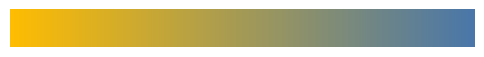

In [6]:

# Create a linear colormap
cmap = mcolors.LinearSegmentedColormap.from_list("GoldToSteelBlue", [graph_palette['foreground']['gold'], graph_palette['foreground']['steelBlue']])

# --- Example: visualize the gradient ---
fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)

# Create gradient data
gradient = np.linspace(0, 1, 256).reshape(1, -1)

ax.imshow(gradient, aspect="auto", cmap=cmap)
ax.set_axis_off()
plt.show()


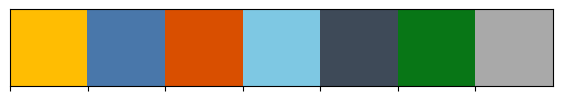

In [7]:
# Background
bg = graph_palette['background']['darkBlue']

# Extract foreground colours
foreground_colors = list(graph_palette["foreground"].values())
background_colors = list(graph_palette["background"].values())

# Create a Seaborn palette
sns_palette = sns.color_palette(foreground_colors)

# Optional: Set as default palette
sns.set_palette(sns_palette)

# Preview the palette
sns.palplot(sns_palette)
plt.show()

In [8]:
sdf.shape

(66366, 52)

In [9]:
sdf.columns

Index(['Apogee', 'Category', 'Class', 'Class Desc', 'CosparID', 'Country',
       'Country Code', 'Decay Date', 'Decay Decade', 'Decay Month',
       'Decay Month No', 'Decay Year', 'Diameter', 'In Orbit', 'Inc',
       'Launch Date', 'Launch Decade', 'Launch Month', 'Launch Month No',
       'Launch Year', 'Length', 'Lifespan Days', 'Lifespan Months',
       'Lifespan Years', 'Manufacturer Code', 'Manufacturer Latitude',
       'Manufacturer Long Name', 'Manufacturer Longitude',
       'Manufacturer Parent', 'Manufacturer Short Name', 'Mass', 'Name',
       'Operator Code', 'Operator Latitude', 'Operator Long Name',
       'Operator Longitude', 'Operator Parent', 'Operator Short Name',
       'Perigee', 'Primary Category', 'Primary Category Desc', 'Program',
       'Program Root', 'Secondary Category', 'Secondary Category Desc',
       'Shape', 'Span', 'State', 'Status', 'Status Desc', 'Type', 'Type Desc'],
      dtype='object')

## Graphs for Presentation

Need to create:

- Objects added by year, showing remaining in orbit
- Pie chart: Breakdown of objects by category (satellites, rocket bodies, debris).
- Bar chart: Payload categories (military, comms, scientific, etc.).
- Bar chart or map: Top countries or organisations responsible for objects in orbit.
- Histogram: Time between launch and re-entry for satellites.
- Visual: Timeline or scatter plot of known collisions or near misses. ... where do we get this data?


Create some filtered datasets

In [10]:
# Filter dataframe for satellites still in orbit
sdf_in_orbit = sdf[sdf['In Orbit'] == True]

# Filter for Type == 'P'
sdf_payloads_in_orbit = sdf_in_orbit[sdf_in_orbit['Type'] == 'P']

# Ensure dates are parsed
sdf['Launch Date'] = pd.to_datetime(sdf['Launch Date'], errors='coerce')

# Filter for objects still in orbit
in_orbit_df = sdf[sdf['In Orbit'] == True].dropna(subset=['Launch Date'])

# Group by year for cumulative count
cumulative_by_year = in_orbit_df.groupby(in_orbit_df['Launch Date'].dt.year).size().cumsum()

# Group by year for launches (all objects)
launches_by_year = sdf.dropna(subset=['Launch Date']).groupby(sdf['Launch Date'].dt.year).size()


## Objects added by year, showing remaining in orbit

In [11]:
fig = go.Figure()

# Add cumulative line
fig.add_trace(go.Scatter(
    x=cumulative_by_year.index,
    y=cumulative_by_year.values,
    #mode='lines+markers',
    mode='lines',
    name='Cumulative In Orbit',
    line=dict(color='#4977AA', width=3),
    marker=dict(color='white', size=6)
))

# Add yearly launches as bars
fig.add_trace(go.Bar(
    x=launches_by_year.index,
    y=launches_by_year.values,
    name='Launches per Year',
    marker_color='#FFBD02'
))

# Apply custom styling
fig.update_layout(
    title='Launches vs Cumulative Objects In Orbit',
    title_font=dict(color='#FFBD02', size=22),
    plot_bgcolor='#0F1A38',
    paper_bgcolor='#0F1A38',
    font=dict(color='white'),
    xaxis=dict(title='Year', color='white', gridcolor='white'),
    yaxis=dict(title='Count', color='white', gridcolor='white'),
    legend=dict(font=dict(color='white')),
    barmode='overlay',
    width=1200,
    height=500
)

fig.show()

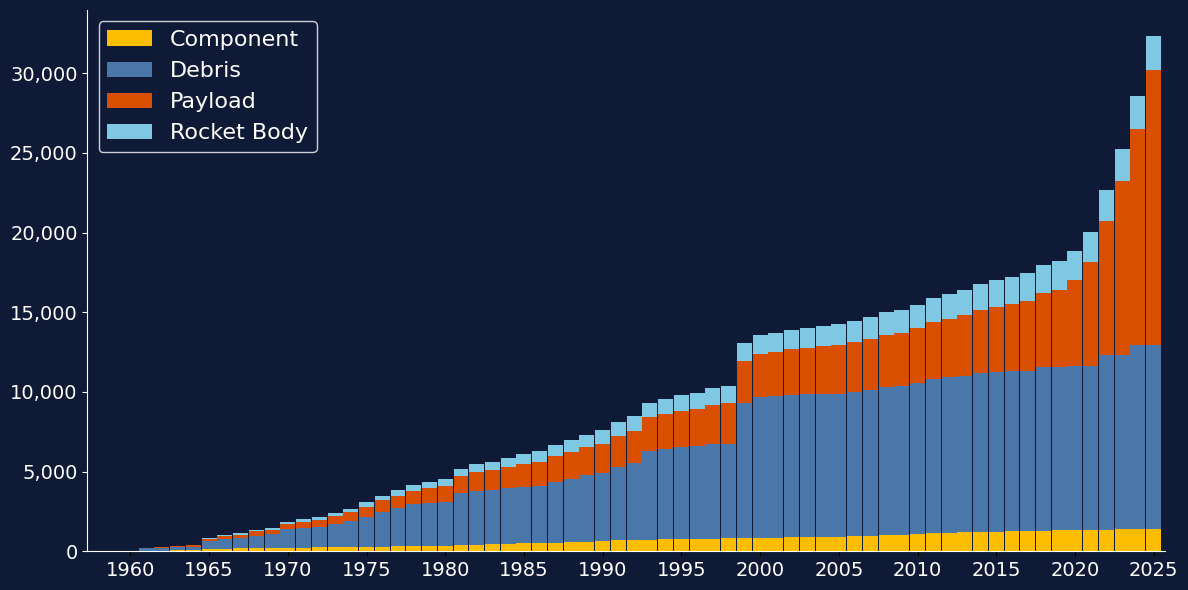

In [56]:
# Step 1: Filter for satellites currently in orbit
df_orbit = sdf_in_orbit[sdf_in_orbit["In Orbit"] == True].copy()

# Step 2: Extract launch year (assuming you have a 'Launch Date' column)
df_orbit["Year"] = pd.to_datetime(df_orbit["Launch Date"]).dt.year

# Step 3: Count objects by Year + Type Desc
counts_by_year_type = (
    df_orbit.groupby(["Year", "Type Desc"])
    .size()
    .reset_index(name="Count")
)

# Step 4: Pivot to wide format
pivot_counts = counts_by_year_type.pivot(index="Year", columns="Type Desc", values="Count").fillna(0)

# Step 5: Compute cumulative counts over time
pivot_cumulative = pivot_counts.cumsum()

# Step 6: Plot stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6), facecolor=bg)
ax.set_facecolor(bg)

pivot_cumulative.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=foreground_colors[:len(pivot_cumulative.columns)],
    width=0.95
)

# Get the years as an array
years = pivot_cumulative.index.astype(int).to_numpy()

# Find positions where the year is a multiple of 5 (adjust start if needed)
mask = (years % 5 == 0)

# Positions on the axis are 0..len(years)-1
positions = np.arange(len(years))[mask]
tick_labels = years[mask]

ax.set_xticks(positions)
ax.set_xticklabels(tick_labels, color="white", rotation=0, fontsize=14)
ax.set_xlabel("", labelpad=0)

# Styling (unchanged)
#ax.set_title("Cumulative In-Orbit Objects by Year and Type", color="white", fontsize=18, pad=20)
#ax.set_ylabel("Cumulative Number of Objects", color="white", fontsize=14)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.tick_params(axis="y", colors="white", labelsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')

legend = plt.legend( labelcolor="white", fontsize=16)
legend.get_frame().set_facecolor(bg)
legend.get_frame().set_edgecolor("white")

plt.tight_layout()
plt.show()


## Breakdown of objects by category (satellites, rocket bodies, debris).

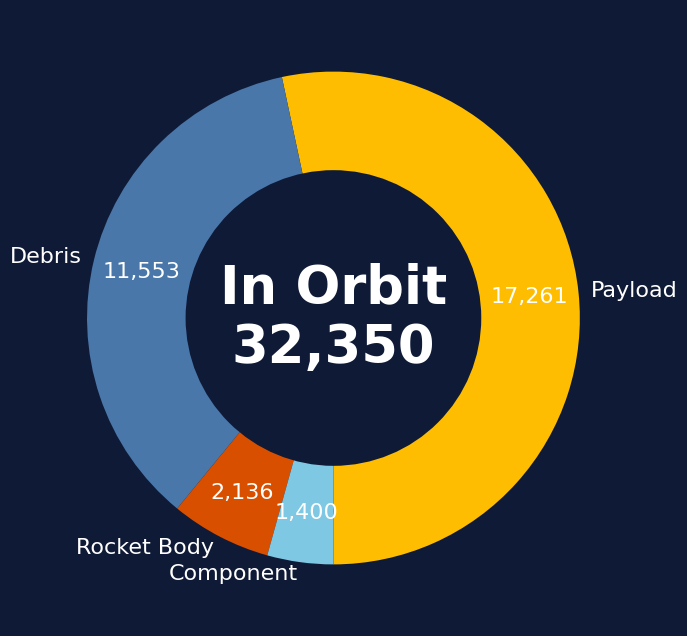

In [12]:
# Count by Type Desc
type_counts = sdf_in_orbit['Type Desc'].value_counts()

# Create figure
fig, ax = plt.subplots(figsize=(8, 8), facecolor=bg)
ax.set_facecolor(bg)

# Donut chart
wedges, texts, autotexts = ax.pie(
    type_counts,
    labels=type_counts.index,
    #autopct='%1.1f%%',
    autopct=lambda pct: f"{int(round(pct/100.*type_counts.sum())):,}",  # show counts
    pctdistance=0.80,    # move counts outward
    labeldistance=1.05,    # move labels outward
    startangle=270,
    colors=foreground_colors[:len(type_counts)],
    textprops={'color': 'white', 'fontsize': 16}
)

# Make it a Donut Plot
centre_circle = plt.Circle((0, 0), 0.60, fc=bg)
fig.gca().add_artist(centre_circle)

# Add centre annotation
plt.text(0, 0, f"In Orbit\n{type_counts.sum():,}", ha='center', va='center',
         color='white', fontsize=38, fontweight='bold')

plt.show()

## Payload categories (military, comms, scientific, etc.).

**Donut Chart**

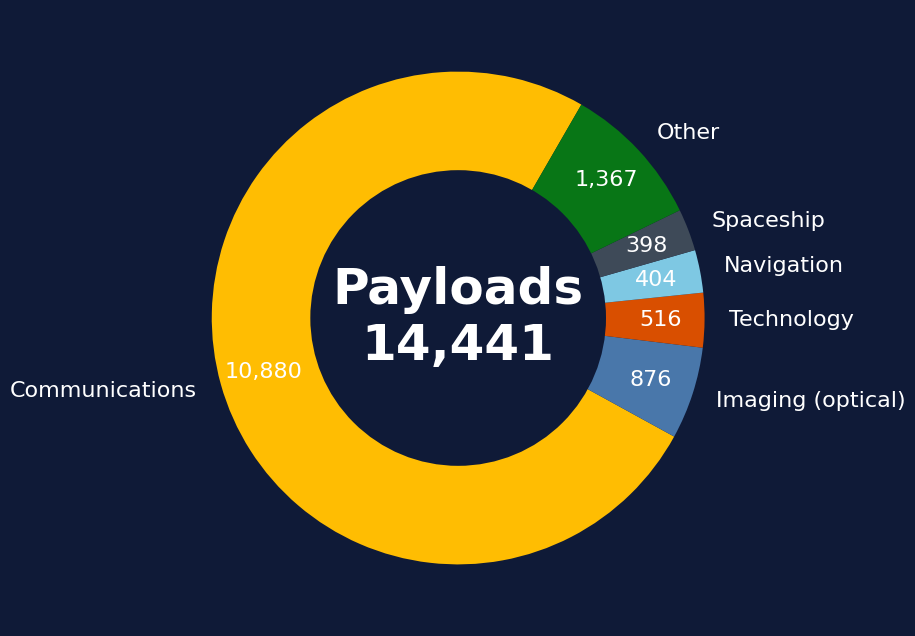

In [102]:
# Count by Category Desc
category_counts_orbit = sdf_payloads_in_orbit['Primary Category Desc'].value_counts()

# Keep top 5 and combine the rest into "Other"
top_n = 5
top_categories = category_counts_orbit[:top_n]
other_sum = category_counts_orbit[top_n:].sum()

# Append "Other" if there are remaining categories
if other_sum > 0:
    top_categories['Other'] = other_sum

# Create figure with darkBlue background
fig, ax = plt.subplots(figsize=(8, 8), facecolor=bg)
ax.set_facecolor(bg)

# Donut chart
wedges, texts, autotexts = ax.pie(
    top_categories,
    labels=top_categories.index,
    autopct=lambda pct: f"{int(round(pct/100.*top_categories.sum())):,}",  # show counts
    startangle=60,
    colors=foreground_colors[:len(top_categories)],
    textprops={'color': 'white', 'fontsize': 16},
    pctdistance=0.82,    # move counts outward
    labeldistance=1.1    # move labels outward
)
ax.set_aspect('equal')

# Make it a donut
centre_circle = plt.Circle((0, 0), 0.60, fc=bg)
fig.gca().add_artist(centre_circle)

# Add centre annotation
plt.text(0, 0, f"Payloads\n{top_categories.sum():,}", ha='center', va='center',
         color='white', fontsize=36, fontweight='bold')

plt.show()


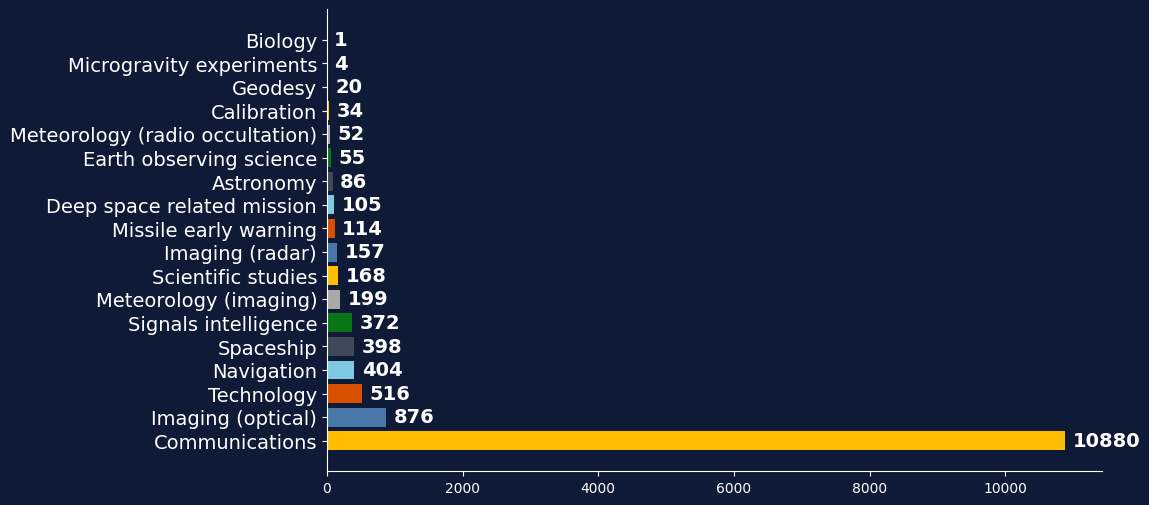

In [101]:
# Count by Category Desc
category_counts_orbit = sdf_payloads_in_orbit['Primary Category Desc'].value_counts()

# Create figure with darkBlue background
fig, ax = plt.subplots(figsize=(10, 6), facecolor=bg)
ax.set_facecolor(bg)

# Horizontal bar chart
bars = ax.barh(
    category_counts_orbit .index,
    category_counts_orbit .values,
    color=foreground_colors[:len(category_counts_orbit )]
)

# Add counts on bars
for bar, count in zip(bars, category_counts_orbit .values):
    ax.text(
        count + max(category_counts_orbit .values)*0.01,  # small offset
        bar.get_y() + bar.get_height()/2,
        str(count),
        va='center',
        color='white',
        fontsize=14,
        fontweight='bold'
    )

# Style axes
ax.tick_params(axis='y', colors='white', labelsize=14)
ax.tick_params(axis='x', colors='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')

plt.show()


## Type of Payload

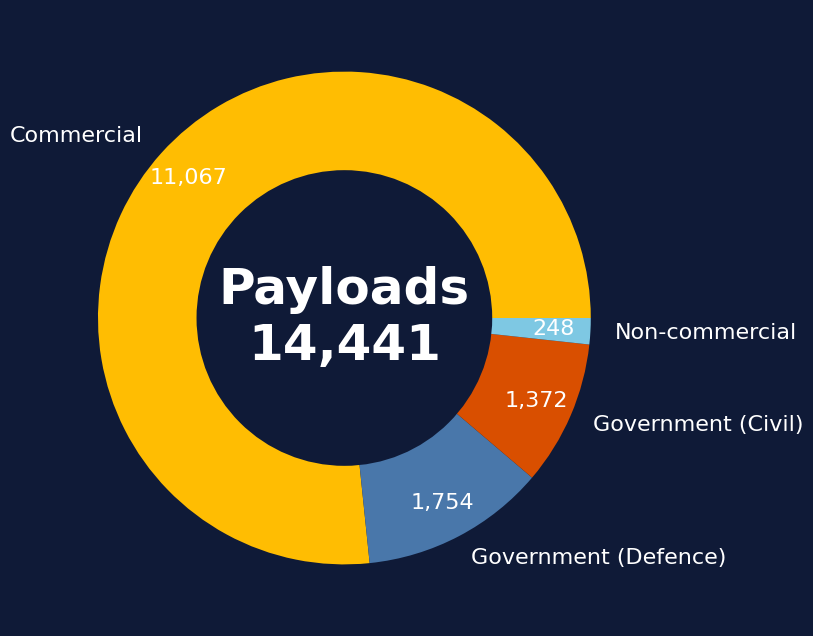

In [103]:
# Count by Class Desc
class_counts_orbit = sdf_payloads_in_orbit['Class Desc'].value_counts()

# Create figure with darkBlue background
fig, ax = plt.subplots(figsize=(8, 8), facecolor=bg)
ax.set_facecolor(bg)

# Donut chart
wedges, texts, autotexts = ax.pie(
    class_counts_orbit,
    labels=class_counts_orbit.index,
    autopct=lambda pct: f"{int(round(pct/100.*class_counts_orbit.sum())):,}",  # show counts
    startangle=0,
    colors=foreground_colors[:len(class_counts_orbit)],
    textprops={'color': 'white', 'fontsize': 16},
    pctdistance=0.85,    # move counts outward
    labeldistance=1.1    # move labels outward
)
ax.set_aspect('equal')

# Make it a donut
centre_circle = plt.Circle((0, 0), 0.60, fc=bg)
fig.gca().add_artist(centre_circle)

# Add centre annotation
plt.text(0, 0, f"Payloads\n{class_counts_orbit.sum():,}", ha='center', va='center',
         color='white', fontsize=36, fontweight='bold')

plt.show()

## Operators and Origins - Masses

In [16]:

# Total mass of all satellites
total_mass = sdf_payloads_in_orbit["Mass"].sum()
print("Total Mass:", total_mass)
print ()

# Total mass by country
mass_by_country = sdf_payloads_in_orbit.groupby("Country")["Mass"].sum()
print (mass_by_country.head(10))
print ()

# Total mass by category
mass_by_category = sdf_payloads_in_orbit.groupby("Primary Category Desc")["Mass"].sum()
print (mass_by_category)


Total Mass: 19410807.274

Country
Algeria        5633.0
Angola         3797.0
Argentina     15657.5
Australia     41718.5
Austria          18.0
Azerbaijan     6738.0
Bahrain           3.0
Bangladesh     3700.0
Belarus        5204.0
Bermuda        8099.0
Name: Mass, dtype: float64

Primary Category Desc
Astronomy                           144160.220
Biology                                259.000
Calibration                           6363.000
Communications                     8443092.719
Deep space related mission          187555.700
Earth observing science              53080.600
Geodesy                              40845.000
Imaging (optical)                   850101.440
Imaging (radar)                     210875.000
Meteorology (imaging)               299945.000
Meteorology (radio occultation)       4403.000
Microgravity experiments              5866.000
Missile early warning               239641.000
Navigation                          602806.000
Scientific studies                  10

### Overall Mass in Orbit

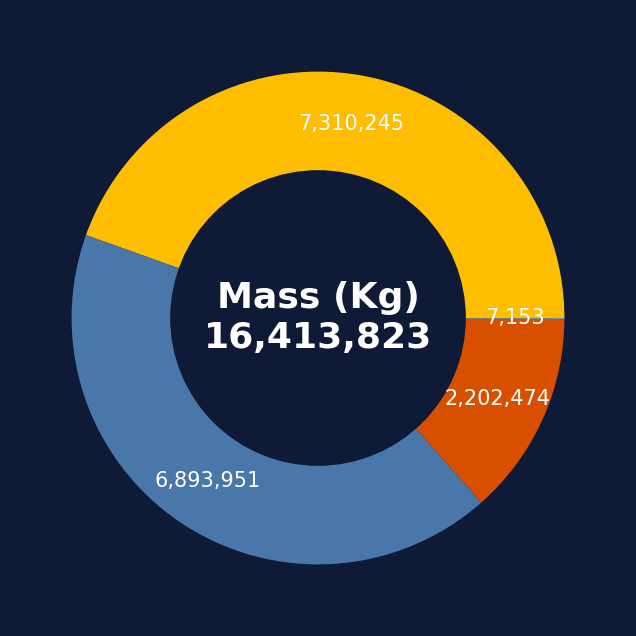

In [99]:

# Aggregate total mass by Class Desc
class_mass_orbit = sdf_payloads_in_orbit.groupby("Class Desc")["Mass"].sum().sort_values(ascending=False)

# Step 3: Create figure with dark background
fig, ax = plt.subplots(figsize=(8, 8), facecolor=bg)
ax.set_facecolor(bg)

# Step 4: Donut chart of mass by Class Desc
wedges, texts, autotexts = ax.pie(
    class_mass_orbit,
    #labels=class_mass_orbit.index,
    labels=None,
    autopct=lambda pct: f"{int(round(pct/100.*class_mass_orbit.sum())):,}",  # show mass values
    startangle=0,
    colors=foreground_colors[:len(class_mass_orbit)],
    textprops={'color': 'white', 'fontsize': 15},
    pctdistance=0.80,
    labeldistance=1.1
)
ax.set_aspect('equal')

# Step 5: Make it a donut
centre_circle = plt.Circle((0, 0), 0.60, fc=bg)
fig.gca().add_artist(centre_circle)

# Step 6: Add centre annotation with total mass
plt.text(
    0, 0,
    f"Mass (Kg)\n{int(class_mass_orbit.sum()):,}",   # formatted with commas
    ha='center', va='center',
    color='white', fontsize=26, fontweight='bold'
)

plt.show()

### Overall Mass in Orbit (Top 5 Countries)

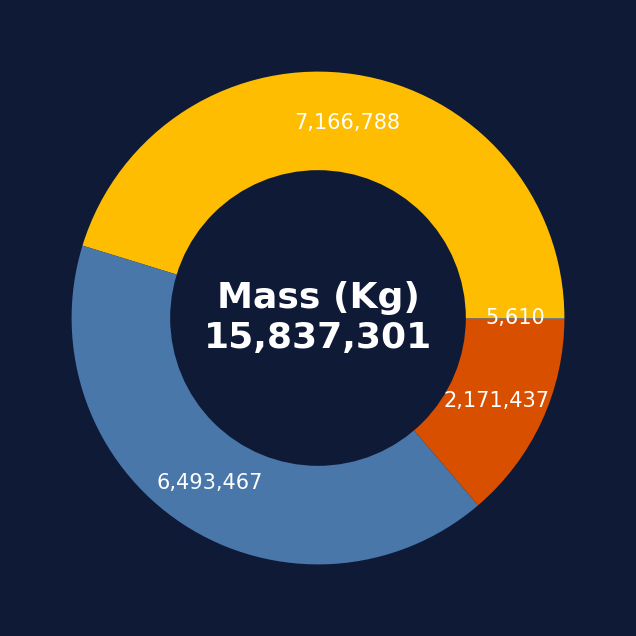

In [121]:
# Step 1: Find top 5 countries by total mass
country_mass_orbit = (
    sdf_payloads_in_orbit.groupby("Country")["Mass"]
    .sum()
    .sort_values(ascending=False)
)
top5_countries = country_mass_orbit.head(5).index

# Step 2: Filter dataset to only those countries
df_top5 = sdf_payloads_in_orbit[sdf_payloads_in_orbit["Country"].isin(top5_countries)]

# Step 3: Aggregate total mass by Class Desc (within top 5 countries)
class_mass_top5 = (
    df_top5.groupby("Class Desc")["Mass"]
    .sum()
    .sort_values(ascending=False)
)

# Step 4: Create figure with dark background
fig, ax = plt.subplots(figsize=(8, 8), facecolor=bg)
ax.set_facecolor(bg)

# Step 5: Donut chart of mass by Class Desc (top 5 countries only)
wedges, texts, autotexts = ax.pie(
    class_mass_top5,
    labels=None,   # no text labels
    autopct=lambda pct: f"{int(round(pct/100.*class_mass_top5.sum())):,}",  # show mass values
    startangle=0,
    colors=foreground_colors[:len(class_mass_top5)],
    textprops={'color': 'white', 'fontsize': 15},
    pctdistance=0.80,
    labeldistance=1.1
)
ax.set_aspect('equal')

# Step 6: Make it a donut
centre_circle = plt.Circle((0, 0), 0.60, fc=bg)
fig.gca().add_artist(centre_circle)

# Step 7: Add centre annotation with total mass
plt.text(
    0, 0,
    f"Mass (Kg)\n{int(class_mass_top5.sum()):,}",   # formatted with commas
    ha='center', va='center',
    color='white', fontsize=26, fontweight='bold'
)

plt.show()


Mass by Project / Program

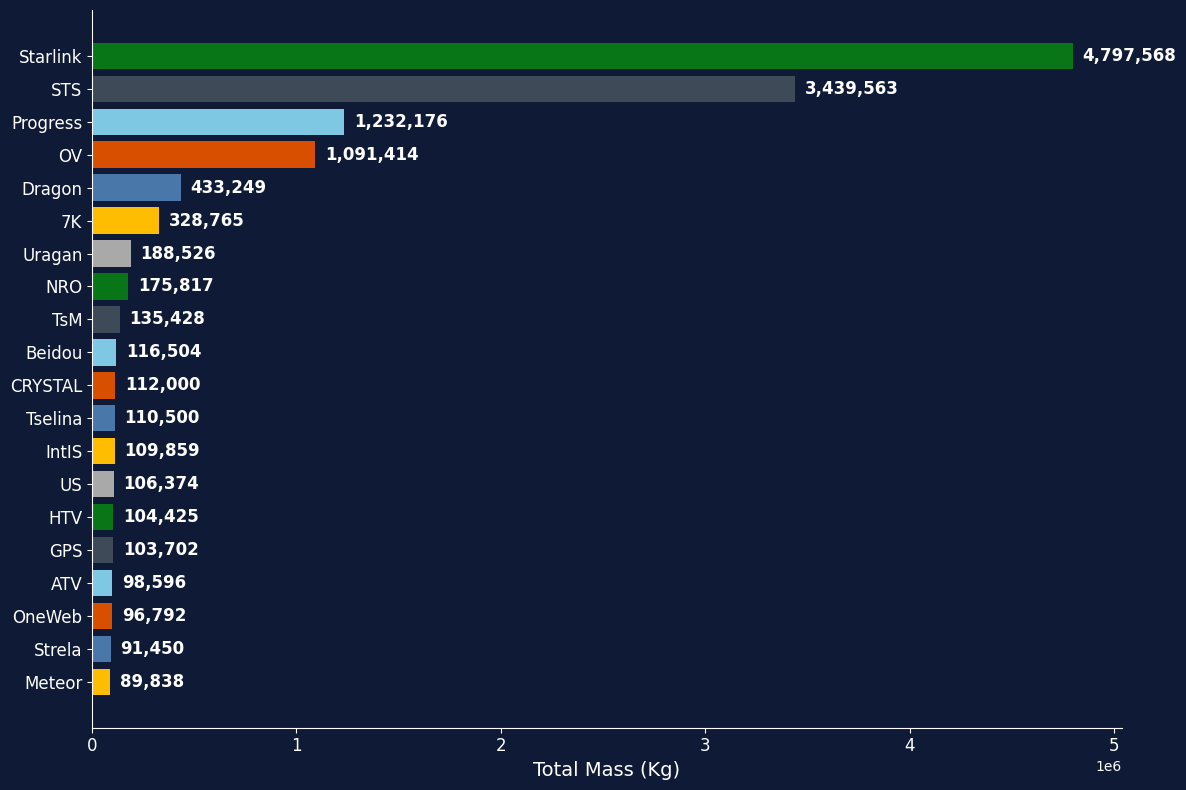

In [18]:
# Aggregate total mass by Program Root (Project)
mass_by_program = (
    sdf_payloads_in_orbit.groupby("Program Root")["Mass"]
    .sum()
    .sort_values(ascending=True) 
    .tail(20)                    
)

# Create figure
fig, ax = plt.subplots(figsize=(12, 8), facecolor=bg)
ax.set_facecolor(bg)

# Plot horizontal bar chart
bars = ax.barh(
    mass_by_program.index,
    mass_by_program.values,
    color=foreground_colors[:len(mass_by_program)]
)

# Add labels at end of bars
for bar, value in zip(bars, mass_by_program.values):
    ax.text(
        value + max(mass_by_program.values)*0.01,   # small offset
        bar.get_y() + bar.get_height()/2,
        f"{int(value):,}",                        # formatted with commas
        va="center",
        color="white",
        fontsize=12,
        fontweight="bold"
    )

# Style axes
#ax.set_title("Top 20 Programs by Total Satellite Mass", color="white", fontsize=18, pad=20)
ax.set_xlabel("Total Mass (Kg)", color="white", fontsize=14)
ax.tick_params(axis="y", colors="white", labelsize=12)
ax.tick_params(axis="x", colors="white", labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')

plt.tight_layout()
plt.show()


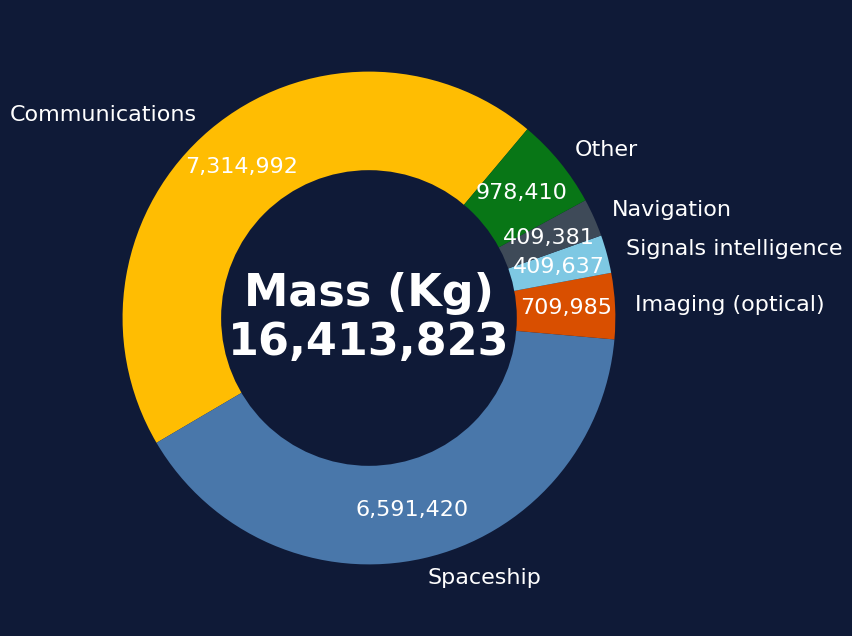

In [114]:
# Aggregate total mass by Primary Category Desc
category_mass_orbit = (
    sdf_payloads_in_orbit.groupby("Primary Category Desc")["Mass"]
    .sum()
    .sort_values(ascending=False)
)

# Keep top 5 and combine the rest into "Other"
top_n = 5
top_categories = category_mass_orbit[:top_n]
other_sum = category_mass_orbit[top_n:].sum()

if other_sum > 0:
    top_categories["Other"] = other_sum

# Create figure with dark background
fig, ax = plt.subplots(figsize=(8, 8), facecolor=bg)
ax.set_facecolor(bg)

# Donut chart of mass by top 5 categories
wedges, texts, autotexts = ax.pie(
    top_categories,
    labels=top_categories.index,
    autopct=lambda pct: f"{int(round(pct/100.*top_categories.sum())):,}",  # show mass values
    startangle=50,
    colors=foreground_colors[:len(top_categories)],
    textprops={'color': 'white', 'fontsize': 16},
    pctdistance=0.8,
    labeldistance=1.08
)
ax.set_aspect('equal')

# Make it a donut
centre_circle = plt.Circle((0, 0), 0.60, fc=bg)
fig.gca().add_artist(centre_circle)

# Add centre annotation with total mass
plt.text(
    0, 0,
    f"Mass (Kg)\n{int(top_categories.sum()):,}",
    ha='center', va='center',
    color='white', fontsize=32, fontweight='bold'
)

plt.show()


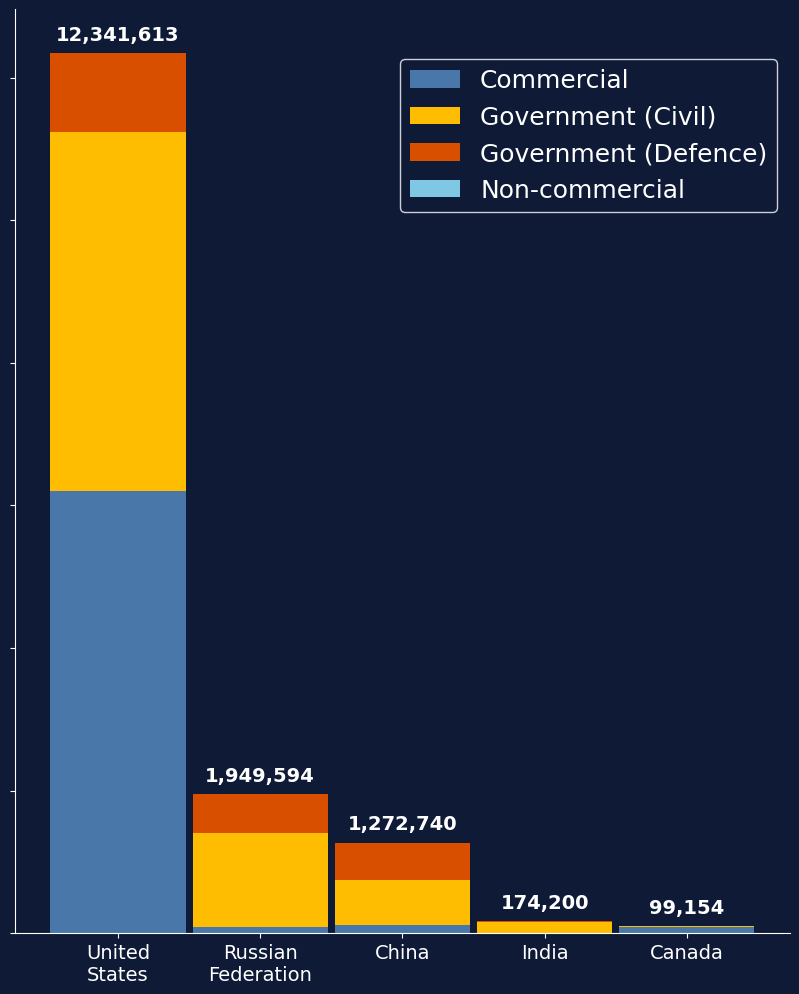

In [100]:
# Aggregate total mass per country
country_mass = sdf_payloads_in_orbit.groupby("Country")["Mass"].sum().sort_values(ascending=False)

# Select top 5 countries, then reverse order (smallest → largest)
top_countries = country_mass.head(5).sort_values(ascending=False).index

# Filter data for those countries
df_top = sdf_payloads_in_orbit[sdf_payloads_in_orbit["Country"].isin(top_countries)]

# Aggregate mass by Country + Class Desc
mass_by_country_class = df_top.groupby(["Country", "Class Desc"])["Mass"].sum().reset_index()

# Pivot for stacked bar chart
pivot_data = mass_by_country_class.pivot(index="Country", columns="Class Desc", values="Mass").fillna(0)

# Reindex to enforce ascending order
pivot_data = pivot_data.loc[top_countries]

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(10, 12), facecolor=bg)
ax.set_facecolor(bg)

# This chart requires custom foreground colour ordering to match with the other chart on the same page
# Attention to detail! :)

temp_foreground_colours = [
    graph_palette['foreground']['steelBlue'],
    graph_palette['foreground']['gold'],
    graph_palette['foreground']['burntOrange'],
    graph_palette['foreground']['skyBlue'],
]

pivot_data.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.95,
    color=temp_foreground_colours[:len(pivot_data.columns)]
)

# Compute totals for each column (country)
totals = pivot_data.sum(axis=1)
# Annotate totals above each bar
for i, total in enumerate(totals):
    ax.text(
        i, total + (0.01 * totals.max()),   # add 1% of max as vertical gap
        f"{total:,.0f}", 
        ha="center", va="bottom",
        color="white", fontsize=14, fontweight="bold"
    )

# Replace the offset text with custom string
ax.yaxis.get_offset_text().set_visible(False)   # hide the 1e7

# Replace spaces with newlines for stacked labels
labels = [label.replace(" ", "\n") for label in pivot_data.index]

# Apply labels with horizontal centering
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(
    labels,
    color="white",
    fontsize=12,
    rotation=0,      # keep horizontal
    ha="center"      # center align under tick
)

ax.set_yticklabels([])   # hides the labels but keeps tick marks


ax.xaxis.label.set_visible(False)
ax.tick_params(axis="x", colors="white", labelsize=14, rotation=0)
ax.tick_params(axis="y", colors="white", labelsize=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')

legend = plt.legend(labelcolor="white", fontsize=18, loc="upper right", bbox_to_anchor=(1, 0.96))
legend.get_frame().set_facecolor(bg)   # set legend background to bg
legend.get_frame().set_edgecolor("white")  
plt.show()


Didn't use this one

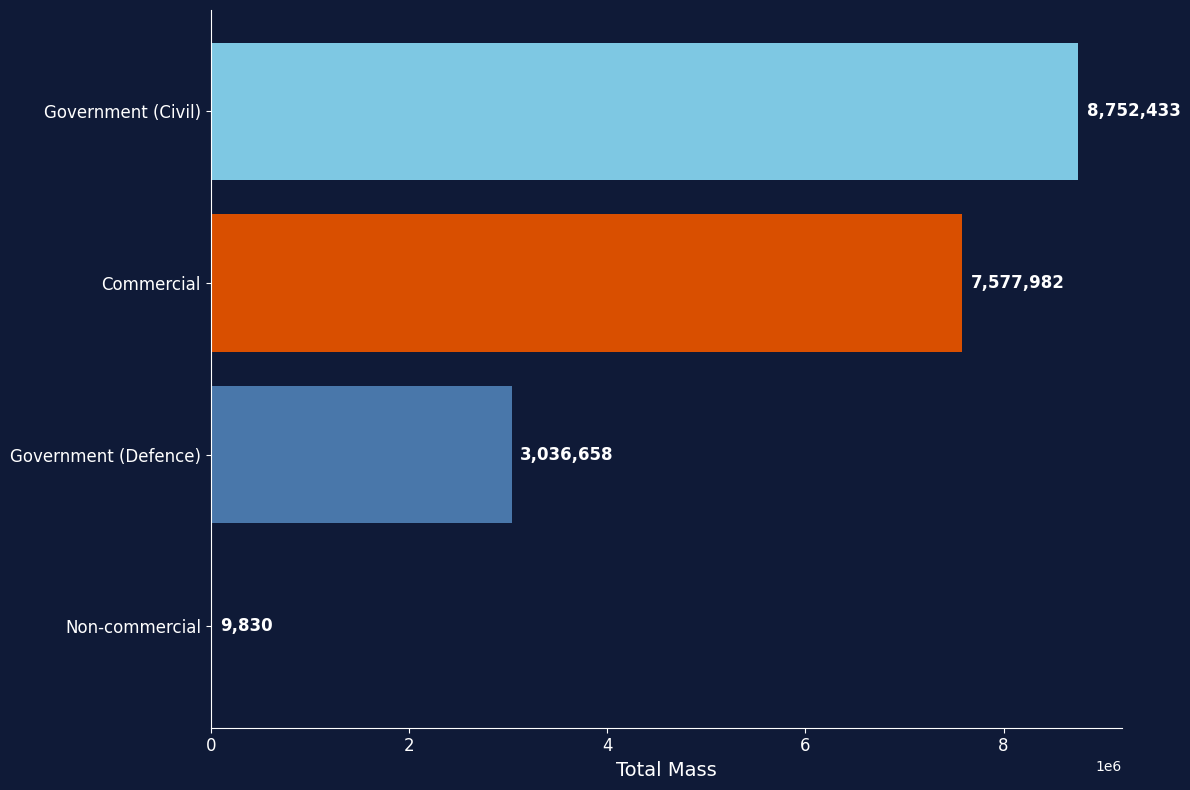

In [20]:
import matplotlib.pyplot as plt

# Step 1: Aggregate total mass by Class Desc
mass_by_class = (
    sdf_payloads_in_orbit.groupby("Class Desc")["Mass"]
    .sum()
    .sort_values(ascending=True)   # ascending so smallest at top
)

# Step 2: Create figure
fig, ax = plt.subplots(figsize=(12, 8), facecolor=bg)
ax.set_facecolor(bg)

# Step 3: Plot horizontal bar chart
bars = ax.barh(
    mass_by_class.index,
    mass_by_class.values,
    color=foreground_colors[:len(mass_by_class)]
)

# Step 4: Add labels at end of bars
for bar, value in zip(bars, mass_by_class.values):
    ax.text(
        value + max(mass_by_class.values)*0.01,   # small offset
        bar.get_y() + bar.get_height()/2,
        f"{int(value):,}",                        # formatted with commas
        va="center",
        color="white",
        fontsize=12,
        fontweight="bold"
    )

# Step 5: Style axes
#ax.set_title("Total Satellite Mass by Class Desc", color="white", fontsize=18, pad=20)
ax.set_xlabel("Total Mass", color="white", fontsize=14)
ax.tick_params(axis="y", colors="white", labelsize=12)
ax.tick_params(axis="x", colors="white", labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')

plt.tight_layout()
plt.show()


### More fun stuff below :)

In [21]:
avg_lifetime = sdf[sdf['Type Desc'].str.startswith('P', na=False)].groupby('Country')['Lifespan Years'].mean().reset_index()
avg_lifetime.columns = ['Country', 'AvgLifetime']
avg_lifetime = avg_lifetime.sort_values('AvgLifetime', ascending=False).head(20)

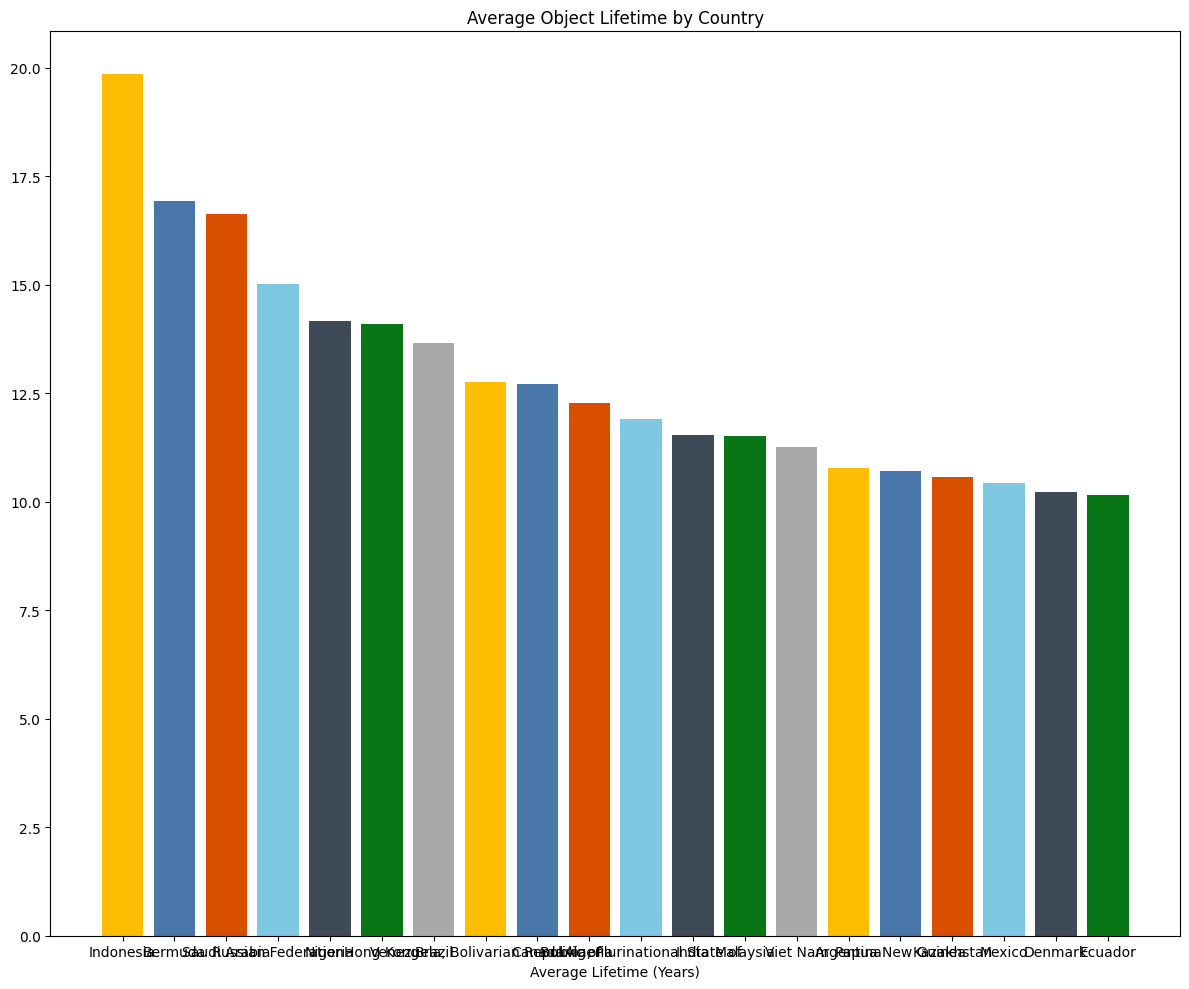

In [22]:
plt.figure(figsize=(12, 10))
plt.bar(avg_lifetime['Country'], avg_lifetime['AvgLifetime'], color=foreground_colors)
plt.xlabel('Average Lifetime (Years)')
plt.title('Average Object Lifetime by Country')
plt.tight_layout()
plt.show()

In [86]:
import pandas as pd
from datetime import datetime

df = sdf_in_orbit.copy()

df["start"] = pd.to_datetime(df["Launch Date"])
df["end"] = pd.to_datetime(df["Decay Date"])  # or Deactivation/Reentry/Last Contact
df["still_active"] = df["In Orbit"]

# If active, use "today" as placeholder end for duration and mark censored
today = pd.Timestamp.today()
df["observed_end"] = df["end"].fillna(today)
df["duration_years"] = (df["observed_end"] - df["start"]).dt.days / 365.25
df["event_observed"] = (~df["still_active"]).astype(int)  # 1=ended, 0=censored


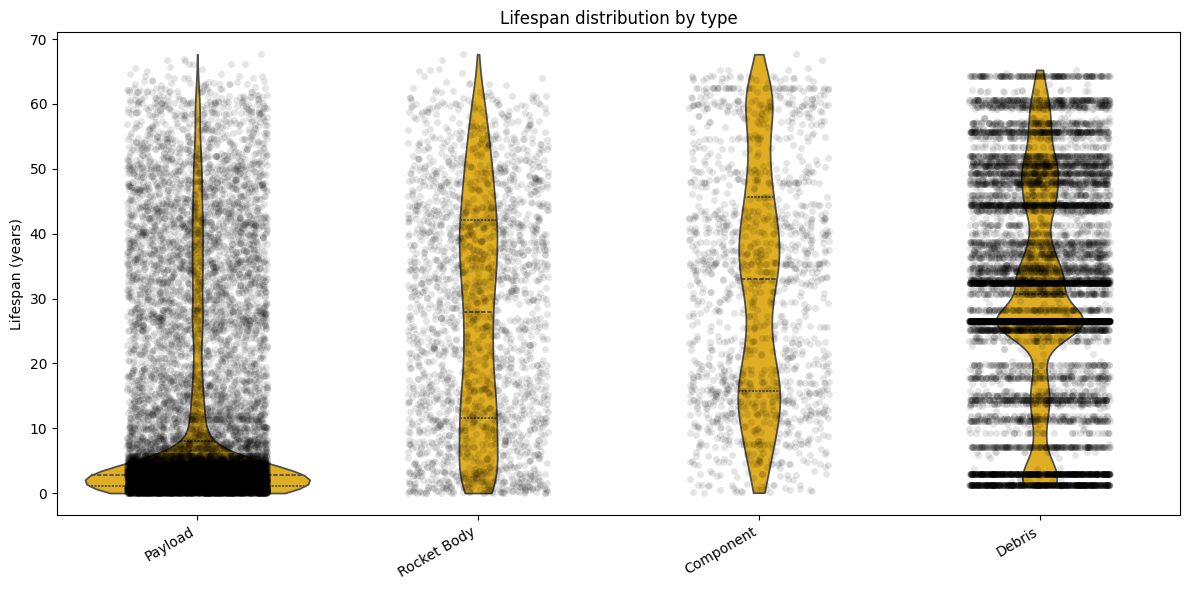

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df, x="Type Desc", y="duration_years", inner="quartile", cut=0
)
sns.stripplot(
    data=df, x="Type Desc", y="duration_years", color="black", alpha=0.1, jitter=0.25
)
plt.ylabel("Lifespan (years)")
plt.xlabel("")
plt.xticks(rotation=30, ha="right")
plt.title("Lifespan distribution by type")
plt.tight_layout()
plt.show()


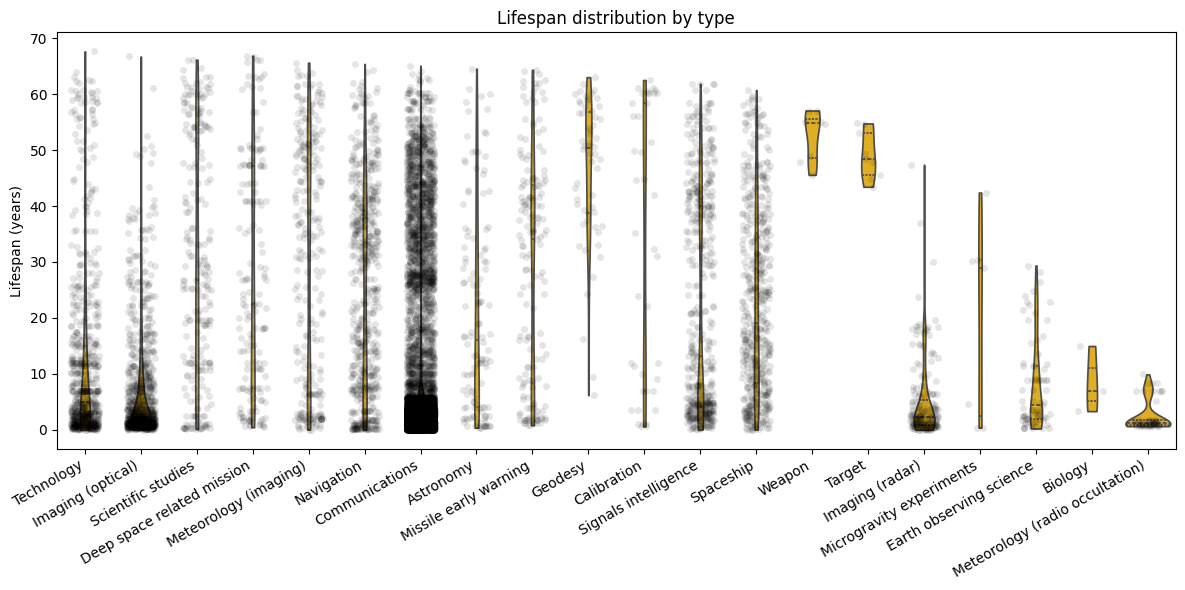

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df, x="Primary Category Desc", y="duration_years", inner="quartile", cut=0
)
sns.stripplot(
    data=df, x="Primary Category Desc", y="duration_years", color="black", alpha=0.1, jitter=0.25
)
plt.ylabel("Lifespan (years)")
plt.xlabel("")
plt.xticks(rotation=30, ha="right")
plt.title("Lifespan distribution by type")
plt.tight_layout()
plt.show()


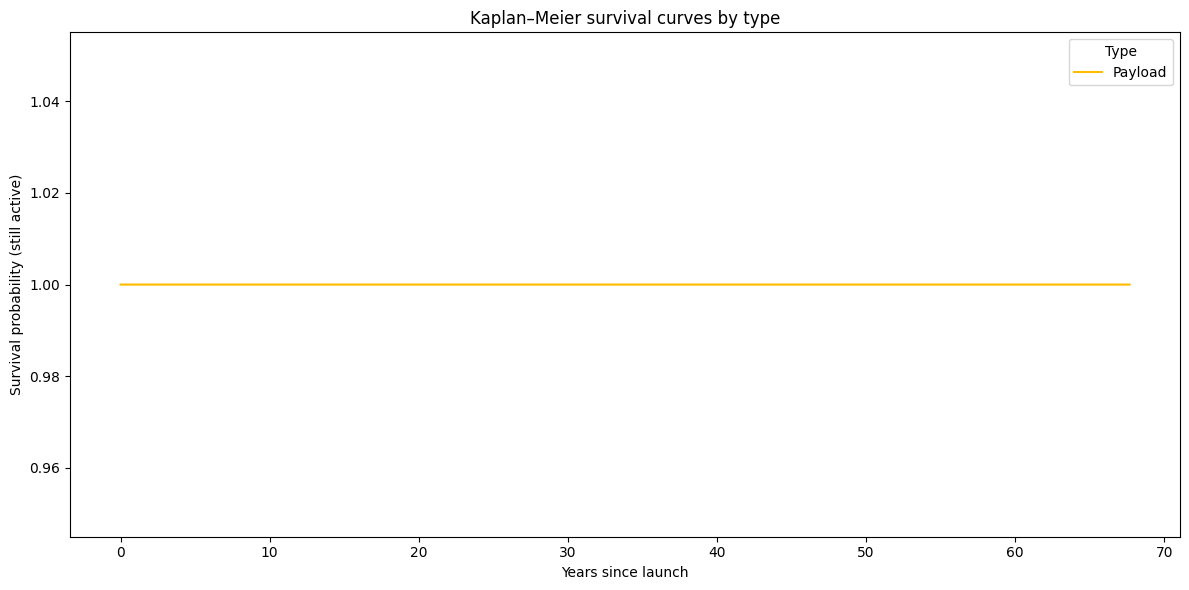

In [84]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(12, 6))
for t, g in df.groupby("Type Desc"):
    kmf.fit(g["duration_years"], event_observed=g["event_observed"], label=t)
    kmf.plot(ci_show=True)

plt.ylabel("Survival probability (still active)")
plt.xlabel("Years since launch")
plt.title("Kaplan–Meier survival curves by type")
plt.legend(title="Type")
plt.tight_layout()
plt.show()


In [85]:
summary = []
for t, g in df.groupby("Type Desc"):
    kmf.fit(g["duration_years"], event_observed=g["event_observed"])
    summary.append({
        "Type": t,
        "Median lifespan (years)": kmf.median_survival_time_,
        "n": len(g),
        "censored_%": 100 * (1 - g["event_observed"].mean())
    })

summary_df = pd.DataFrame(summary).sort_values("Median lifespan (years)", ascending=False)


In [23]:


# Drop rows with missing values in hierarchy columns
sdf_payloads_in_orbit = sdf_payloads_in_orbit.dropna(subset=['Country', 'Class Desc'])

# Aggregate counts for clarity
agg_df = sdf_payloads_in_orbit.groupby(['Country', 'Class Desc']).size().reset_index(name='Count')


# Step 5: Create sunburst chart
fig = px.sunburst(
    agg_df,
    path=['Class Desc', 'Country'],
    values='Count',
    title='Top 20 Countries by Object Volume (Grouped by Class)',
    color='Country'
)

fig.update_layout(
    width=1200,   # Increase width (default is ~700)
    height=800,   # Increase height (default is ~450)
    margin=dict(t=50, l=25, r=25, b=25)
)
fig.show()


## Rubbish Charts :-)

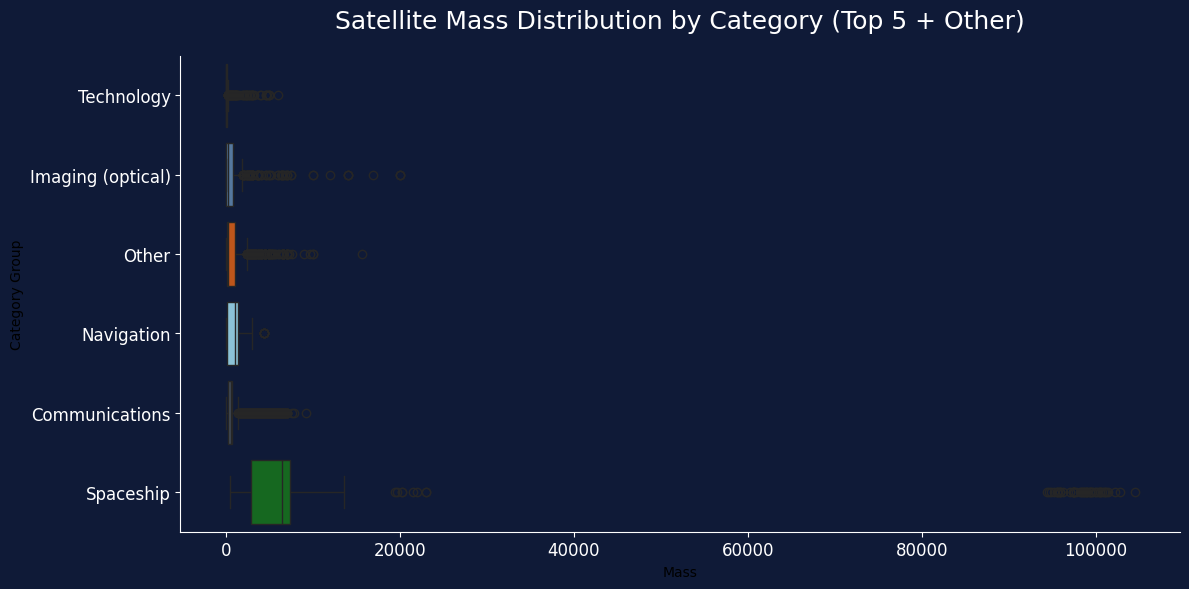

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data: only keep top 5 categories + Other
category_counts_orbit = sdf_payloads_in_orbit['Primary Category Desc'].value_counts()
top_n = 5
top_categories = category_counts_orbit.index[:top_n]

# Mark all others as "Other"
sdf_mass = sdf_payloads_in_orbit.copy()
sdf_mass['Category Group'] = sdf_mass['Primary Category Desc'].where(
    sdf_mass['Primary Category Desc'].isin(top_categories),
    other='Other'
)

# Create figure
fig, ax = plt.subplots(figsize=(12, 6), facecolor=bg)
ax.set_facecolor(bg)

# Boxplot of Mass by Category Group
sns.boxplot(
    data=sdf_mass,
    x='Mass',
    y='Category Group',
    palette=foreground_colors[:len(sdf_mass['Category Group'].unique())],
    ax=ax
)

# Style axes
ax.set_title("Satellite Mass Distribution by Category (Top 5 + Other)",
             color='white', fontsize=18, pad=20)
ax.tick_params(axis='x', colors='white', labelsize=12)
ax.tick_params(axis='y', colors='white', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')

plt.tight_layout()
plt.show()


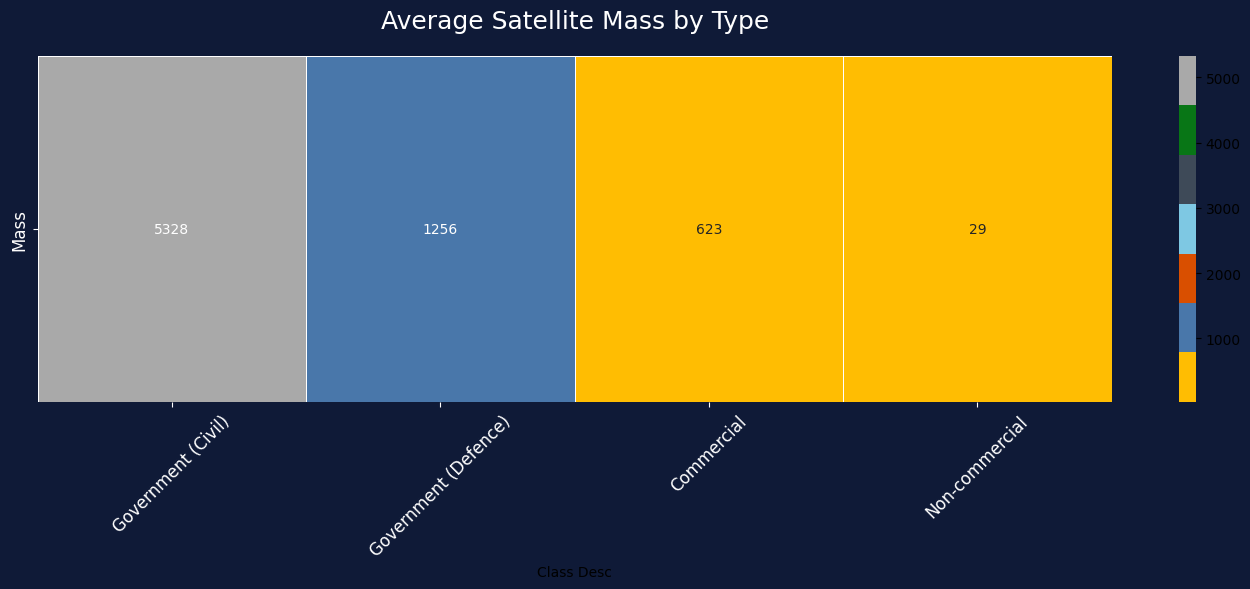

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate: average mass per Type Desc
mass_by_type = sdf_payloads_in_orbit.groupby("Class Desc")["Mass"].mean().sort_values(ascending=False)

# Convert to DataFrame for heatmap
heatmap_data = mass_by_type.to_frame().T  # transpose so Type Desc are columns

# Create figure
fig, ax = plt.subplots(figsize=(14, 6), facecolor=bg)
ax.set_facecolor(bg)

# Heatmap
sns.heatmap(
    heatmap_data,
    cmap=sns.color_palette(foreground_colors, as_cmap=True),
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar=True,
    ax=ax
)

# Style
ax.set_title("Average Satellite Mass by Type", color="white", fontsize=18, pad=20)
ax.tick_params(axis="x", colors="white", labelsize=12, rotation=45)
ax.tick_params(axis="y", colors="white", labelsize=12)

plt.tight_layout()
plt.show()


In [26]:
import pandas as pd
import plotly.express as px

# Aggregate total mass by Country
mass_by_country = (
    sdf_payloads_in_orbit.groupby("Country")["Mass"]
    .sum()
    .reset_index()
)

# Sort for clarity
mass_by_country = mass_by_country.sort_values("Mass", ascending=False)

# Treemap
fig = px.treemap(
    mass_by_country,
    path=["Country"],
    values="Mass",
    color="Mass",
    color_continuous_scale=foreground_colors,  # use your palette
)

# Style background
fig.update_layout(
    paper_bgcolor=bg,
    plot_bgcolor=bg,
    font=dict(color="white")
)

fig.show()


In [125]:
import geopandas as gpd

# Load the built-in world dataset
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

# Inspect columns
print(world.columns)
# ['pop_est', 'continent', 'name', 'iso_a3', 'gdp_md_est', 'geometry']

# Example: create a mapping from country name to continent
country_to_continent = dict(zip(world["name"], world["continent"]))

# Now you can map your dataframe's Country column
df["Continent"] = df["Country"].map(country_to_continent)



AttributeError: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

In [31]:
import pandas as pd
import plotly.express as px

# Step 1: Aggregate total mass per country
mass_by_country = (
    sdf_payloads_in_orbit.groupby("Country")["Mass"]
    .sum()
    .reset_index()
)

# Step 2: Build choropleth map
fig = px.choropleth(
    mass_by_country,
    locations="Country",          # country names
    locationmode="country names", # match by name
    color="Mass",                 # shading by total mass
    color_continuous_scale=[graph_palette['foreground']['gold'], graph_palette['foreground']['steelBlue']],  # your palette
    title="Total Satellite Mass by Country"
)

# Step 3: Style background
fig.update_layout(
    paper_bgcolor=bg,
    plot_bgcolor=bg,
    font=dict(color="white"),
    geo=dict(bgcolor=bg)
)

fig.show()


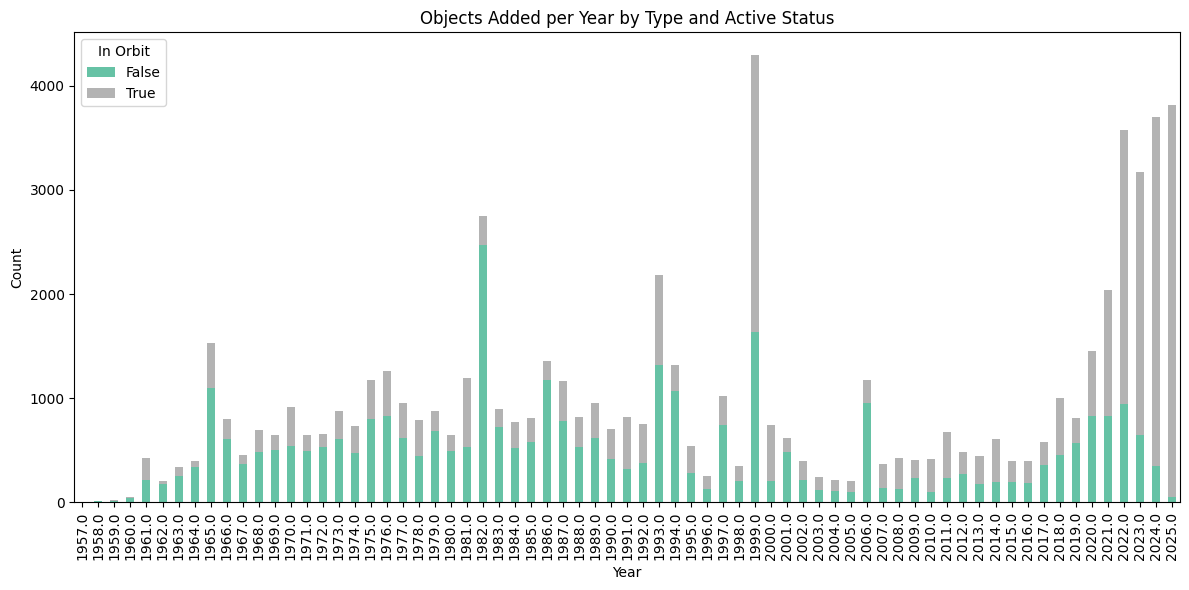

In [32]:
grouped = sdf.groupby(['Launch Year', 'In Orbit']).size().unstack(fill_value=0)

# Plotting
grouped.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title('Objects Added per Year by Type and Active Status')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='In Orbit')
plt.tight_layout()
plt.show()

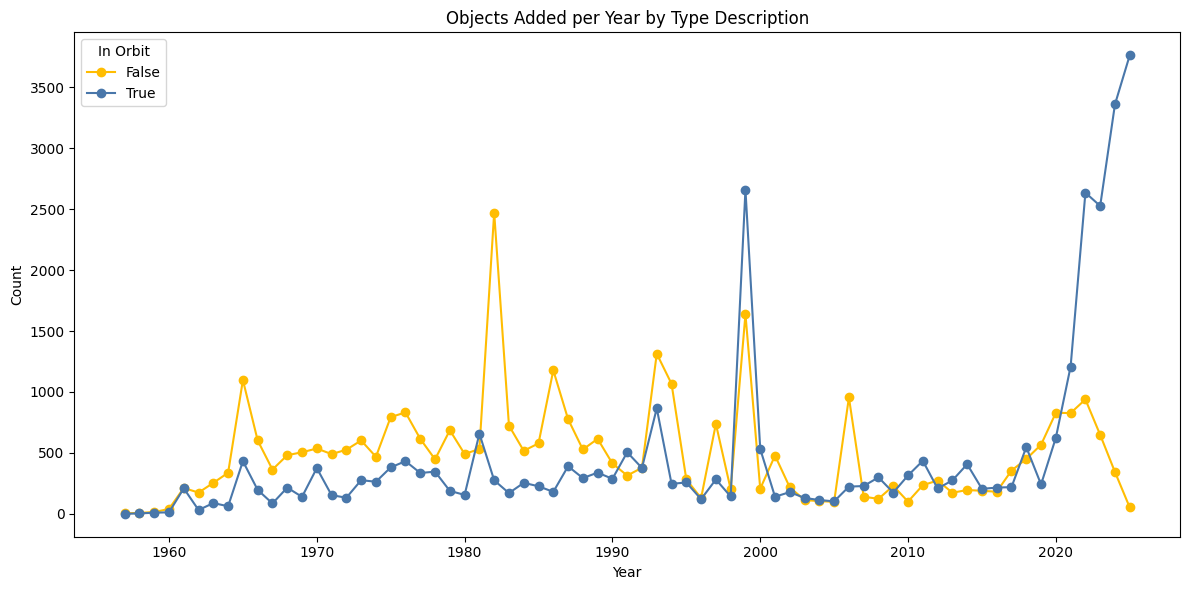

In [34]:
grouped = sdf.groupby(['Launch Year',  'In Orbit']).size().unstack(fill_value=0).sort_index()
#'Type Desc',
grouped.plot(kind='line', marker='o', figsize=(12, 6), color=foreground_colors)
plt.title('Objects Added per Year by Type Description')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='In Orbit')
plt.tight_layout()
plt.show()

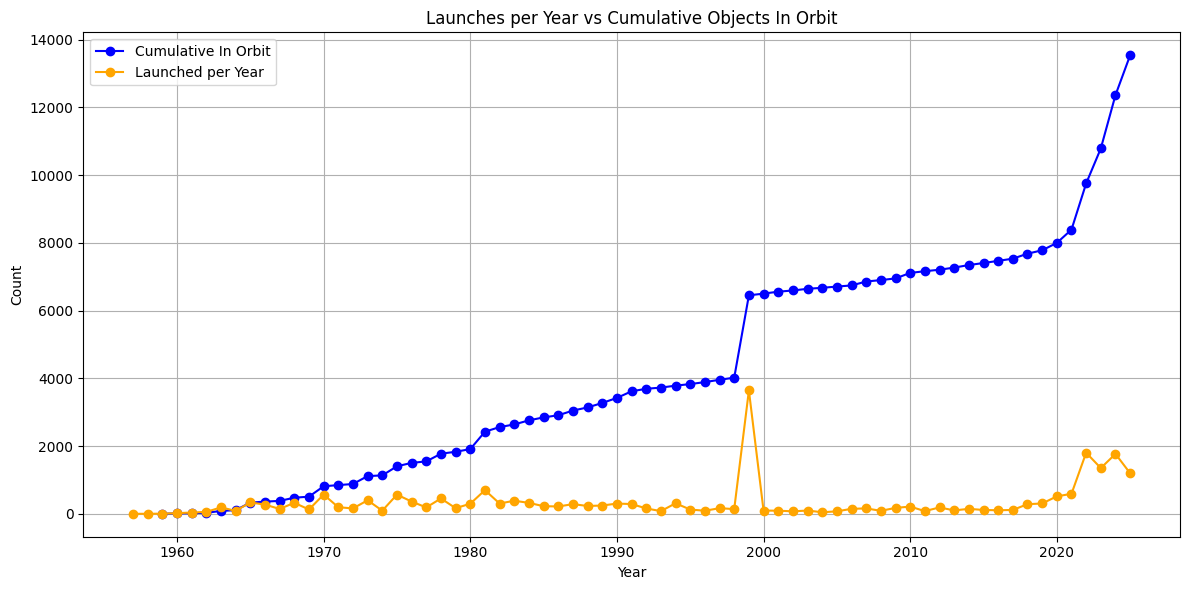

In [ ]:



# Plot both series
plt.figure(figsize=(12, 6))
plt.plot(cumulative_by_year.index, cumulative_by_year.values, label='Cumulative In Orbit', color='blue', marker='o')
plt.plot(launches_by_year.index, launches_by_year.values, label='Launched per Year', color='orange', marker='o')

# Customise chart
plt.title('Launches per Year vs Cumulative Objects In Orbit')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# NEED TO FINISH THIS SECTION

Idea notes:

Graphs to Draw

Disteibution curves

Life time of object in years vs type


—. Box plot 
ployly interactive box plot

Bar charts

X = top 10 countries for satellites
Y = Counts of 


Per top ten countries (and second chart for owner), by year, violin plot for active or not?

Objects which appear and disappear in the same year. (< 12 months)

How much debris is still in orbit? 
Percentage of the debris that belongs to a given country / owner.

Parent… if there is no parent, copy owner?

Class and Categories



Presentation

- Discuss the Issue
- Discuss the types of satellite out there - class and category

Life span… 
By company — 
By type and class


Sunburst. — country… then class/.

- 


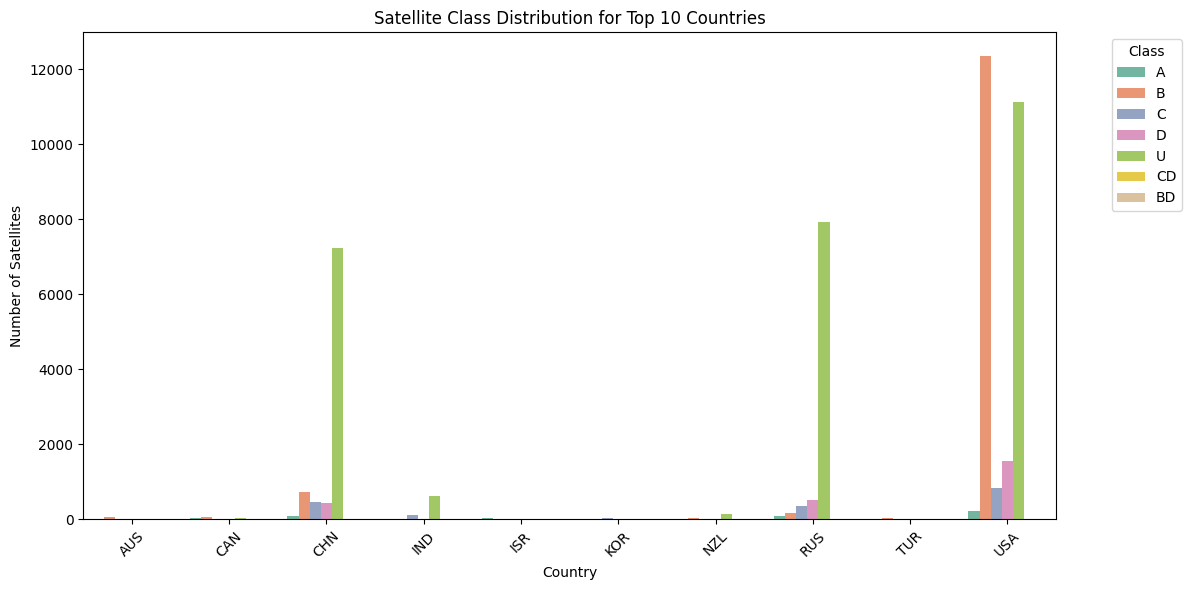

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get top 10 countries by satellite count
top_countries = sdf['Country Code'].value_counts().nlargest(10).index

# Filter for top countries
filtered_df = sdf[sdf['Country Code'].isin(top_countries)]

# Group by CountryCode and Class
grouped = filtered_df.groupby(['Country Code', 'Class']).size().reset_index(name='Count')

# Create the grouped bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=grouped,
    x='Country Code',
    y='Count',
    hue='Class',
    palette='Set2'
)

# Customize the plot
plt.title('Satellite Class Distribution for Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Satellites')
plt.xticks(rotation=45)
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

